In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [11]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [10]:
print(titanic.shape)
print(titanic.info())
print(titanic.describe())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None
         survived      pclass         age       sibsp       parch        fare


In [7]:
missing_counts = titanic.isnull().sum()
missing_percentages = (titanic.isnull().mean() * 100).round(2)

missing_data = pd.DataFrame({
    'Missing Values': missing_counts, 
    'Percentage (%)': missing_percentages
})
display(missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

,Missing Values,Percentage (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [3]:
survived = 0
dead = 0
for sur in titanic['survived']:
    if sur == 1:
        survived = survived + 1
    else:
        dead = dead + 1
print('number of survived: ' + str(survived))
print('number of dead: ' + str(dead))
print('ratio of survived to all: ' + str(survived/(survived+dead)))

number of survived: 342
number of dead: 549
ratio of survived to all: 0.3838383838383838


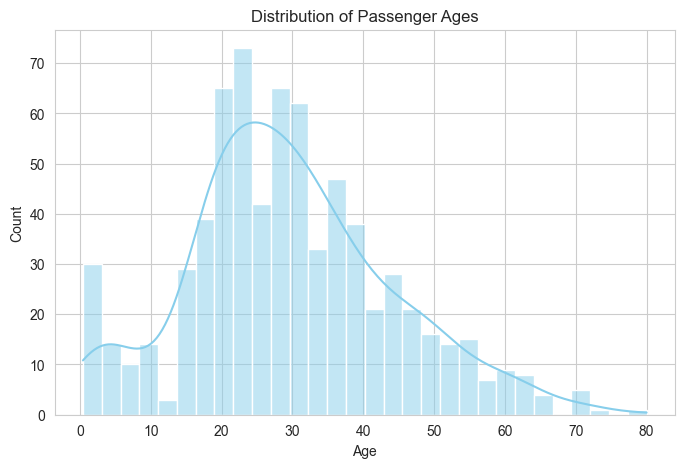

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=titanic, x='age', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_22724\702959391.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='sex', y='survived', palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_22724\702959391.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='pclass', y='survived', palette='Set1')


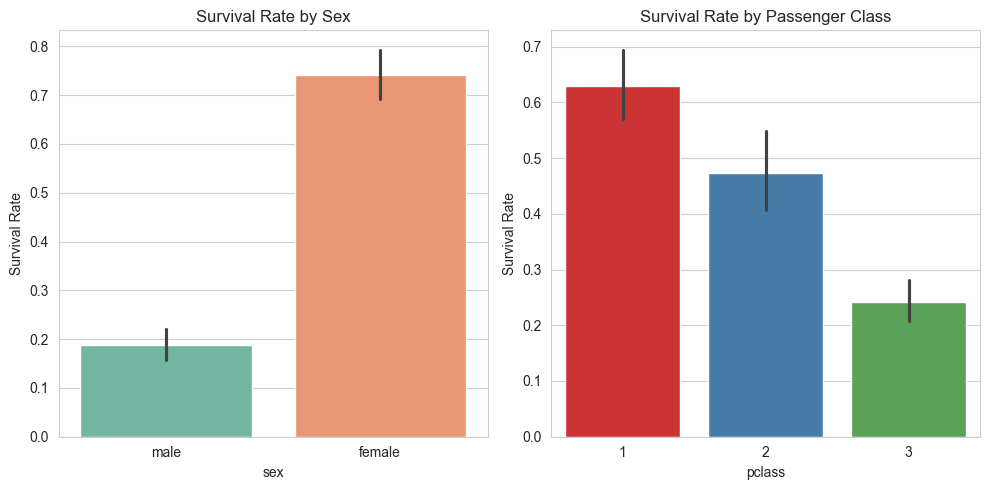

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=titanic, x='sex', y='survived', palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')

plt.subplot(1, 2, 2)
sns.barplot(data=titanic, x='pclass', y='survived', palette='Set1')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

In [ ]:
titanic.fillna({'age': titanic['age'].median(), 'embarked': titanic['embarked'].mode()[0]}, inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [18]:
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])

In [36]:
ohe = OneHotEncoder(sparse_output=False, dtype=int)

embarked_encoded = ohe.fit_transform(titanic[['embarked']])

feature_names = ohe.get_feature_names_out(['embarked'])

embarked_df = pd.DataFrame(embarked_encoded, columns=feature_names, index=titanic.index)
titanic = pd.concat([titanic, embarked_df], axis=1)

titanic = titanic.drop('embarked', axis=1)

display(titanic.head())

,survived,pclass,sex,age,sibsp,parch,fare,family_size,isalone,embarked_0.0,embarked_1.0
0,0,3,1,22.0,1,0,7.2500,2,0,1,0
1,1,1,0,38.0,1,0,71.2833,2,0,1,0
2,1,3,0,26.0,0,0,7.9250,1,1,1,0
3,1,1,0,35.0,1,0,53.1000,2,0,1,0
4,0,3,1,35.0,0,0,8.0500,1,1,1,0


In [37]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic

,survived,pclass,sex,age,sibsp,parch,fare,family_size,isalone,embarked_0.0,embarked_1.0
0,0,3,1,22.0,1,0,7.2500,2,0,1,0
1,1,1,0,38.0,1,0,71.2833,2,0,1,0
2,1,3,0,26.0,0,0,7.9250,1,1,1,0
3,1,1,0,35.0,1,0,53.1000,2,0,1,0
4,0,3,1,35.0,0,0,8.0500,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,1,1,1,0
887,1,1,0,19.0,0,0,30.0000,1,1,1,0
888,0,3,0,28.0,1,2,23.4500,4,0,1,0
889,1,1,1,26.0,0,0,30.0000,1,1,1,0


In [ ]:
drop_cols = ['alive','who','adult_male','embark_town','class','alone']
titanic.drop(columns=drop_cols, inplace=True)

In [40]:
print(titanic.head(), titanic.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   survived      891 non-null    int64  
 1   pclass        891 non-null    int64  
 2   sex           891 non-null    int64  
 3   age           891 non-null    float64
 4   sibsp         891 non-null    int64  
 5   parch         891 non-null    int64  
 6   fare          891 non-null    float64
 7   family_size   891 non-null    int64  
 8   isalone       891 non-null    int64  
 9   embarked_0.0  891 non-null    int64  
 10  embarked_1.0  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB
   survived  pclass  sex   age  sibsp  parch     fare  family_size  isalone  \
0         0       3    1  22.0      1      0   7.2500            2        0   
1         1       1    0  38.0      1      0  71.2833            2        0   
2         1       3    0  26.0      0      0   7.9250      

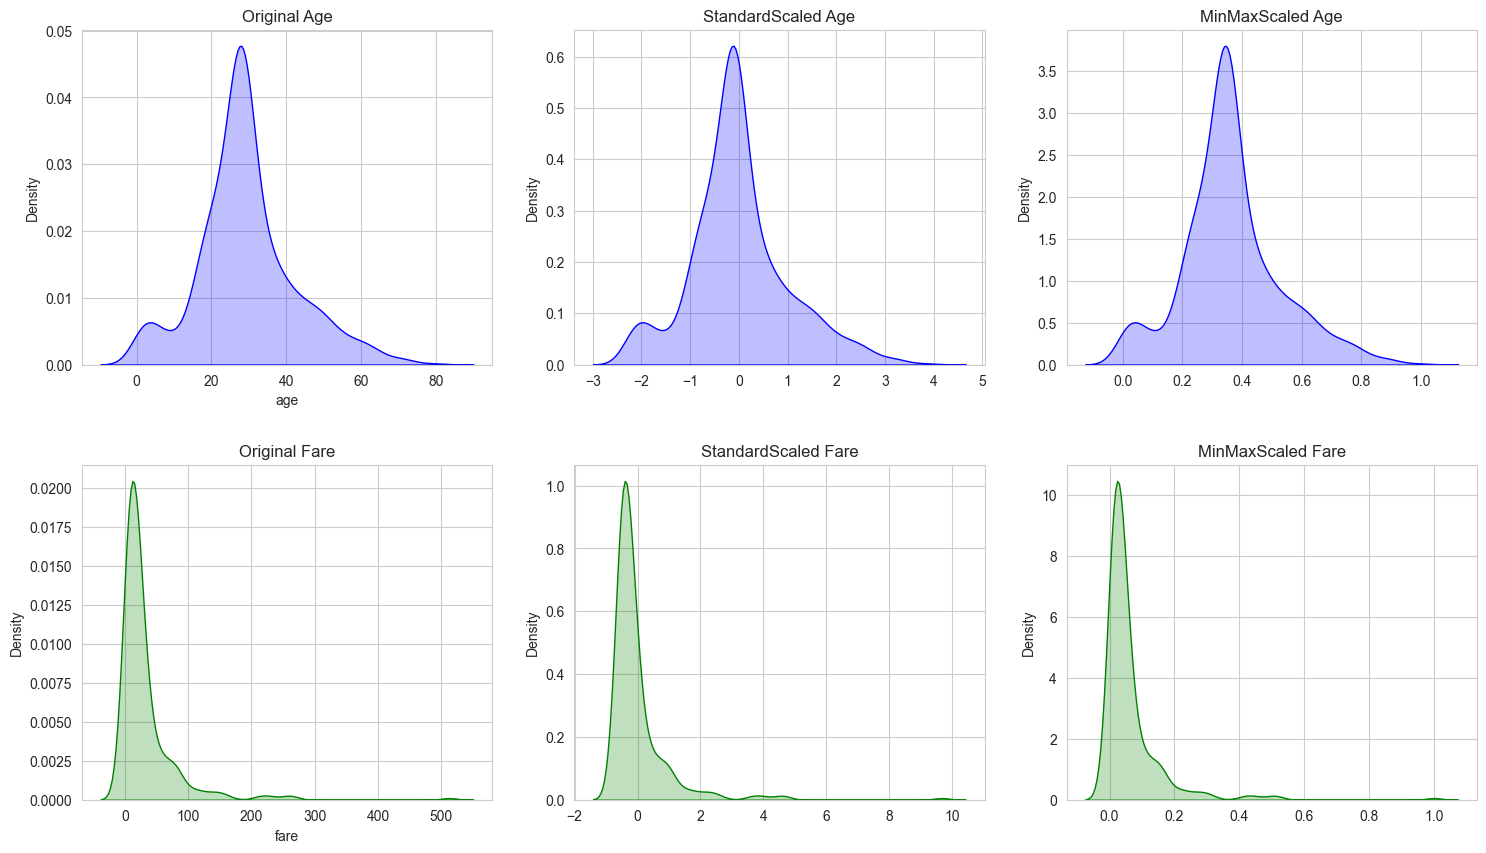

In [41]:
features_to_scale = ['age', 'fare']

scaler_std = StandardScaler()
std_scaled = scaler_std.fit_transform(titanic[features_to_scale])

scaler_minmax = MinMaxScaler()
minmax_scaled = scaler_minmax.fit_transform(titanic[features_to_scale])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3)

sns.kdeplot(titanic['age'], ax=axes[0, 0], fill=True, color='blue').set_title('Original Age')
sns.kdeplot(titanic['fare'], ax=axes[1, 0], fill=True, color='green').set_title('Original Fare')

sns.kdeplot(std_scaled[:, 0], ax=axes[0, 1], fill=True, color='blue').set_title('StandardScaled Age')
sns.kdeplot(std_scaled[:, 1], ax=axes[1, 1], fill=True, color='green').set_title('StandardScaled Fare')

sns.kdeplot(minmax_scaled[:, 0], ax=axes[0, 2], fill=True, color='blue').set_title('MinMaxScaled Age')
sns.kdeplot(minmax_scaled[:, 1], ax=axes[1, 2], fill=True, color='green').set_title('MinMaxScaled Fare')

plt.show()

MixMaxScaler fits all the values between 0 to 1, Standard Scaler centers values into mean of 0 and STD of 1. Both keeps the shape of original

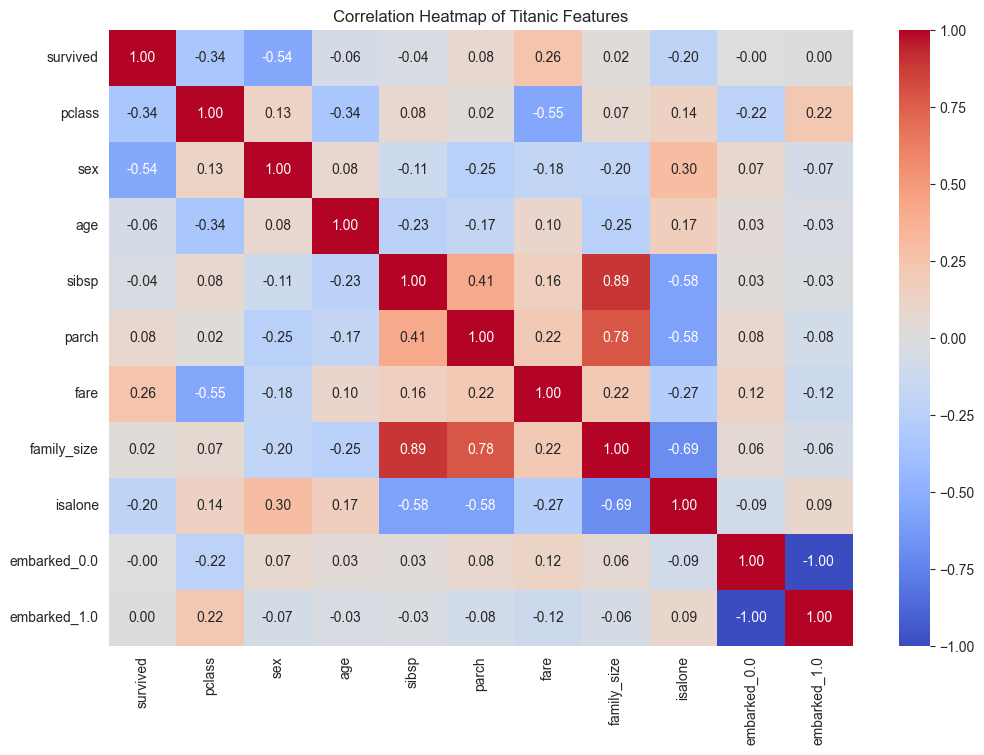

Correlations with Survived:
 fare            0.257307
parch           0.081629
family_size     0.016639
embarked_1.0    0.003650
embarked_0.0   -0.003650
sibsp          -0.035322
age            -0.064910
isalone        -0.203367
pclass         -0.338481
sex            -0.543351
Name: survived, dtype: float64

Selected Features (abs(corr) >= 0.1): ['pclass', 'sex', 'fare', 'isalone']


In [ ]:
numeric = titanic.select_dtypes(include=['number', 'bool'])

corr_matrix = numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Heatmap of Titanic Features")
plt.show()

target_corr = corr_matrix['survived'].drop('survived')
print("Correlations with Survived:\n", target_corr.sort_values(ascending=False))

selected_features = target_corr[abs(target_corr) >= 0.1].index.tolist()
print(f"\nSelected Features (abs(corr) >= 0.1): {selected_features}")

Top features with abs corr>=0.1 are: fare, pclass,sex and isalone. Parch and age are borderline features. After quick research, we can conclude that, actually age and parents/childs played huge role on titanic's survival case.The correlation is low because the relationship is likely non-linear

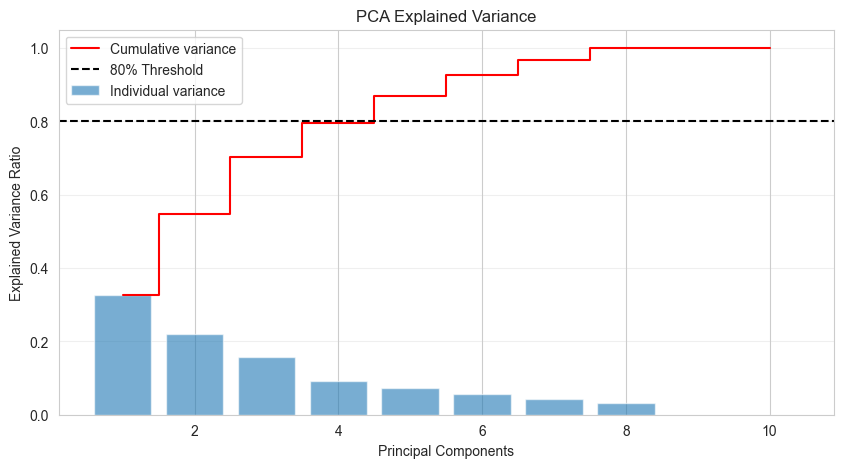

In [46]:
X = numeric.drop(columns=['survived']).fillna(0) 
y = titanic['survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_all = PCA()
pca_all.fit(X_scaled)

explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, align='center', label='Individual variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative variance', color='red')
plt.axhline(y=0.80, color='k', linestyle='--', label='80% Threshold')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('PCA Explained Variance')
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()

4-5 components to capture 80% threshold

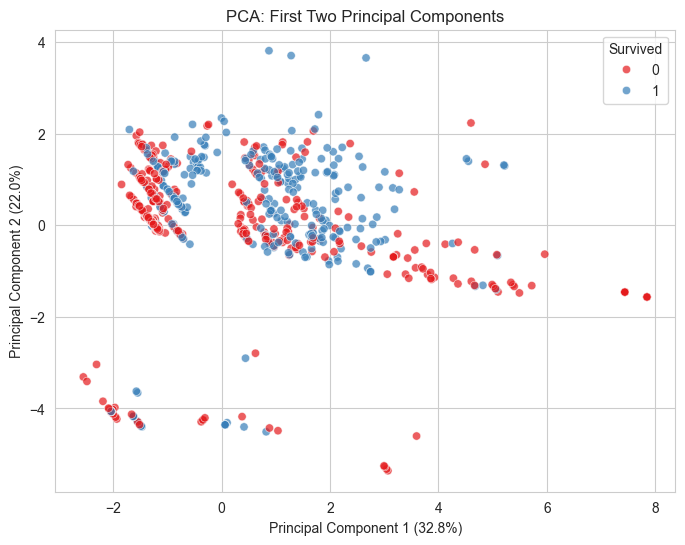

In [47]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, palette='Set1', alpha=0.7)
plt.title('PCA: First Two Principal Components')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='Survived')
plt.show()

PCA does not separate survivors with no-survivors as we can see from scatter plot. There is no line or visible relation to interpret. Overall 54,8% captured variance does not mean we succesfully separated classes. We should not use PCA for this dataset because titanic dataset is heavily filled with categorical datas which is not the best for PCA's mathematical methods